# NeuralAlpha Financial Machine Learning Pipeline

Binary classification pipeline for predicting whether the next price move is UP or DOWN.

In [1]:
import logging
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger("neuralalpha_ml")

MODEL_CHOICE = "random_forest"  # Switch to "logistic_regression" when needed
ARTIFACT_DIR = Path("ml_pipeline/models")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

In [11]:
def normalize_columns(frame: pd.DataFrame) -> pd.DataFrame:
    """Normalize column names for consistent processing."""
    output = frame.copy()
    output.columns = (
        output.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"[^0-9a-z]+", "_", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return output


def get_input_dataframe() -> pd.DataFrame:
    """Return the preloaded df if available; otherwise load the stock and crypto raw datasets."""
    if "df" in globals() and isinstance(globals()["df"], pd.DataFrame):
        logger.info("Using preloaded df from notebook environment.")
        return globals()["df"].copy()

    search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    raw_dir = None
    for root in search_roots:
        candidate = root / "ml_pipeline" / "data" / "raw"
        if candidate.exists():
            raw_dir = candidate
            break

    if raw_dir is None:
        raise FileNotFoundError("No preloaded df found and no ml_pipeline/data/raw directory was available.")

    source_files = [
        raw_dir / "stock_market_data.csv",
        raw_dir / "crypto_market_data.csv",
    ]
    frames = []
    for file_path in source_files:
        if file_path.exists():
            frame = pd.read_csv(file_path)
            frame["dataset"] = file_path.stem
            frames.append(frame)

    if not frames:
        raise FileNotFoundError("No preloaded df found and no raw datasets were available.")

    logger.info("Loaded %d fallback dataset(s) from ml_pipeline/data/raw.", len(frames))
    return pd.concat(frames, ignore_index=True, sort=False)


def infer_price_column(columns: pd.Index) -> str:
    """Infer the current price column used for target engineering."""
    candidates = ["close", "adj_close", "price", "last", "settle"]
    for candidate in candidates:
        if candidate in columns:
            return candidate
    raise ValueError("No usable price column found. Expected one of: close, adj_close, price, last, settle.")


def infer_sort_column(columns: pd.Index) -> str | None:
    """Infer a time column so target creation respects chronology."""
    for candidate in ["date", "timestamp", "datetime", "time"]:
        if candidate in columns:
            return candidate
    return None


def build_target(frame: pd.DataFrame, price_column: str) -> pd.DataFrame:
    """Create the binary target with no leakage by shifting the next price within each logical group."""
    data = frame.copy()
    group_columns = [column for column in ["dataset", "symbol"] if column in data.columns]

    sort_column = infer_sort_column(data.columns)
    if sort_column is not None:
        data[sort_column] = pd.to_datetime(data[sort_column], errors="coerce")

    sort_by = group_columns + ([sort_column] if sort_column is not None else [])
    if sort_by:
        data = data.sort_values(sort_by, kind="mergesort")

    if group_columns:
        next_price = data.groupby(group_columns, dropna=False)[price_column].shift(-1)
    else:
        next_price = data[price_column].shift(-1)

    data["target"] = np.where(next_price.notna(), (next_price > data[price_column]).astype("int8"), np.nan)
    data = data.dropna(subset=["target"]).copy()
    data["target"] = data["target"].astype("int8")
    return data


def drop_irrelevant_columns(frame: pd.DataFrame) -> pd.DataFrame:
    """Drop obvious non-feature columns such as id/date fields."""
    data = frame.copy()
    drop_candidates = ["id", "date", "timestamp", "datetime", "time"]
    existing = [column for column in drop_candidates if column in data.columns]
    if existing:
        data = data.drop(columns=existing)
    return data


def drop_highly_correlated_features(frame: pd.DataFrame, threshold: float = 0.9) -> list[str]:
    """Return the feature columns after removing highly correlated ones."""
    correlation_matrix = frame.corr().abs().fillna(0)
    upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    columns_to_drop = [column for column in upper_triangle.columns if (upper_triangle[column] > threshold).any()]
    selected_columns = [column for column in frame.columns if column not in columns_to_drop]
    return selected_columns


def get_model(model_choice: str) -> object:
    """Return a fast classifier with a lightweight training configuration."""
    if model_choice == "random_forest":
        return RandomForestClassifier(
            n_estimators=50,
            max_depth=6,
            n_jobs=-1,
            random_state=42,
        )
    if model_choice == "logistic_regression":
        return LogisticRegression(max_iter=200, random_state=42)
    raise ValueError("Unsupported model choice. Use 'random_forest' or 'logistic_regression'.")


def build_pipeline(raw_df: pd.DataFrame, model_choice: str = MODEL_CHOICE) -> dict[str, object]:
    """Build, train, evaluate, and persist the ML pipeline artifacts."""
    data = normalize_columns(raw_df)

    if "dataset" not in data.columns:
        data["dataset"] = "input"

    price_column = infer_price_column(data.columns)
    data = build_target(data, price_column=price_column)
    data = drop_irrelevant_columns(data)

    numeric_features = data.select_dtypes(include=[np.number]).drop(columns=["target"], errors="ignore")
    target = data["target"].astype("int8")

    if numeric_features.shape[1] == 0:
        raise ValueError("No numeric features remain after preprocessing.")

    x_train_raw, x_test_raw, y_train, y_test = train_test_split(
        numeric_features,
        target,
        test_size=0.2,
        random_state=42,
        stratify=target,
    )

    imputer = SimpleImputer(strategy="median")
    x_train_imputed = pd.DataFrame(
        imputer.fit_transform(x_train_raw),
        columns=x_train_raw.columns,
        index=x_train_raw.index,
    )
    x_test_imputed = pd.DataFrame(
        imputer.transform(x_test_raw),
        columns=x_train_raw.columns,
        index=x_test_raw.index,
    )

    selected_features = drop_highly_correlated_features(x_train_imputed, threshold=0.9)
    x_train_selected = x_train_imputed[selected_features]
    x_test_selected = x_test_imputed[selected_features]

    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train_selected)
    x_test_scaled = scaler.transform(x_test_selected)

    model = get_model(model_choice)
    model.fit(x_train_scaled, y_train)

    y_pred = model.predict(x_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, digits=4)

    joblib.dump(model, ARTIFACT_DIR / "model.pkl")
    joblib.dump(scaler, ARTIFACT_DIR / "scaler.pkl")

    logger.info("Training completed with %d input features and %d selected features.", numeric_features.shape[1], len(selected_features))
    logger.info("Artifacts saved to %s", ARTIFACT_DIR)

    return {
        "data": data,
        "price_column": price_column,
        "imputer": imputer,
        "scaler": scaler,
        "model": model,
        "feature_columns": list(x_train_raw.columns),
        "selected_features": selected_features,
        "x_test_raw": x_test_raw,
        "x_test": x_test_selected,
        "y_test": y_test.reset_index(drop=True),
        "y_pred": y_pred,
        "accuracy": accuracy,
        "confusion_matrix": cm,
        "classification_report": report,
        "model_choice": model_choice,
    }

In [12]:
raw_df = get_input_dataframe()
artifacts = build_pipeline(raw_df, model_choice=MODEL_CHOICE)

print("Model choice:", artifacts["model_choice"])
print("Price column:", artifacts["price_column"])
print("Selected features:", len(artifacts["selected_features"]))
print("Accuracy:", round(artifacts["accuracy"], 4))
print("Confusion Matrix:\n", artifacts["confusion_matrix"])
print("Classification Report:\n", artifacts["classification_report"])

2026-04-07 00:35:42,630 | INFO | Loaded 2 fallback dataset(s) from ml_pipeline/data/raw.
2026-04-07 00:35:43,093 | INFO | Training completed with 13 input features and 9 selected features.
2026-04-07 00:35:43,094 | INFO | Artifacts saved to ml_pipeline\models


Model choice: random_forest
Price column: close
Selected features: 9
Accuracy: 0.6505
Confusion Matrix:
 [[1621  741]
 [ 912 1455]]
Classification Report:
               precision    recall  f1-score   support

           0     0.6400    0.6863    0.6623      2362
           1     0.6626    0.6147    0.6377      2367

    accuracy                         0.6505      4729
   macro avg     0.6513    0.6505    0.6500      4729
weighted avg     0.6513    0.6505    0.6500      4729



Top 10 Features:
bollinger_upper   0.4303
open              0.2747
rsi               0.1607
volume            0.0533
macd              0.0314
inflation_rate    0.0155
sentiment         0.0118
sentiment_score   0.0116
gdp_growth        0.0108


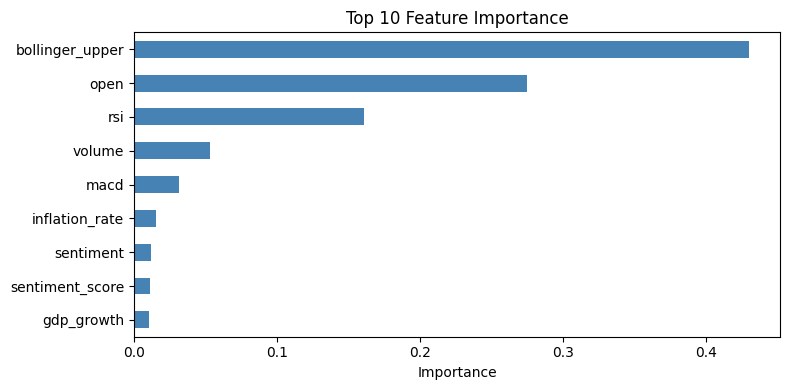

Sample Predictions:
 actual  predicted actual_label predicted_label
      1          1         UP 📈            UP 📈
      0          0       DOWN 📉          DOWN 📉
      0          0       DOWN 📉          DOWN 📉
      1          1         UP 📈            UP 📈
      1          1         UP 📈            UP 📈
      1          0         UP 📈          DOWN 📉
      0          1       DOWN 📉            UP 📈
      0          0       DOWN 📉          DOWN 📉
      1          0         UP 📈          DOWN 📉
      1          1         UP 📈            UP 📈


In [7]:
model = artifacts["model"]
selected_features = artifacts["selected_features"]

if hasattr(model, "feature_importances_"):
    importances = pd.Series(model.feature_importances_, index=selected_features).sort_values(ascending=False).head(10)
elif hasattr(model, "coef_"):
    importances = pd.Series(np.abs(model.coef_).ravel(), index=selected_features).sort_values(ascending=False).head(10)
else:
    importances = pd.Series(dtype=float)

if not importances.empty:
    print("Top 10 Features:")
    print(importances.to_string())

    plt.figure(figsize=(8, 4))
    importances.sort_values().plot(kind="barh", color="steelblue")
    plt.title("Top 10 Feature Importance")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance is not available for the selected model.")

sample_predictions = pd.DataFrame({
    "actual": artifacts["y_test"].head(10).to_numpy(),
    "predicted": artifacts["y_pred"][:10],
})
sample_predictions["actual_label"] = sample_predictions["actual"].map({1: "UP 📈", 0: "DOWN 📉"})
sample_predictions["predicted_label"] = sample_predictions["predicted"].map({1: "UP 📈", 0: "DOWN 📉"})
print("Sample Predictions:")
print(sample_predictions.to_string(index=False))

In [13]:
imputer = artifacts["imputer"]
scaler = artifacts["scaler"]
model = artifacts["model"]
feature_columns = artifacts["feature_columns"]
selected_features = artifacts["selected_features"]

def predict_new(data):
    """Predict UP or DOWN for a new record supplied as a dict or DataFrame."""
    if isinstance(data, dict):
        input_frame = pd.DataFrame([data])
    elif isinstance(data, pd.DataFrame):
        input_frame = data.copy()
    else:
        raise TypeError("data must be a dict or pandas DataFrame")

    input_frame = normalize_columns(input_frame)
    input_frame = input_frame.drop(columns=[column for column in ["id", "date", "timestamp", "datetime", "time", "target"] if column in input_frame.columns], errors="ignore")

    for column in feature_columns:
        if column not in input_frame.columns:
            input_frame[column] = np.nan

    input_frame = input_frame[feature_columns]
    imputed_frame = pd.DataFrame(imputer.transform(input_frame), columns=feature_columns)
    selected_frame = imputed_frame[selected_features]
    scaled_frame = scaler.transform(selected_frame)
    prediction = int(model.predict(scaled_frame)[0])
    return "UP 📈" if prediction == 1 else "DOWN 📉"


demo_row = artifacts["x_test_raw"].head(1).copy()
demo_dict = demo_row.iloc[0].to_dict()
print("Real-time Prediction Demo:", predict_new(demo_dict))

Real-time Prediction Demo: UP 📈


### Deployment Note
The saved artifacts are ready for API integration: `ml_pipeline/models/model.pkl` and `ml_pipeline/models/scaler.pkl`.
For future use, load these artifacts in an API or batch job and call `predict_new(data)` with a dict or DataFrame payload.
